# 🍱 Analisis Sentimen Komentar YouTube — Program MBG (Makan Bergizi Gratis)

**Mahasiswa:** Muhammad Dimas Alfathir  
**Prodi:** Perpustakaan dan Sains Informasi — UIN Malang  
**Tahun:** 2026  

---

## 🗺️ Alur Pipeline

```
Load Data → EDA → Feature Selection → Cleaning → Case Folding → Tokenizing
→ Stopword Removal → Stemming → roBERTta Labeling → Encoding
→ Model Training (LR | NB | RF | SVM) → Evaluasi → Prediksi → Simpan Model
```

---
## ⚙️ STEP 0 — Install Library (Jalankan Sekali)

Jalankan cell ini **hanya pertama kali** untuk menginstall semua dependensi.

In [1]:
# ============================================================
# INSTALL SEMUA LIBRARY
# Jalankan cell ini sekali, lalu restart kernel
# ============================================================
import subprocess, sys

packages = [
    'pandas', 'numpy', 'matplotlib', 'seaborn', 'wordcloud',
    'nltk', 'PySastrawi', 'regex',
    'transformers', 'torch', 'sentencepiece',
    'scikit-learn', 'joblib', 'imbalanced-learn',
    'tqdm', 'ipywidgets'
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
    print(f'✅ {pkg} installed')

print('\n🎉 Semua library berhasil diinstall! Restart kernel sekarang.')

✅ pandas installed
✅ numpy installed
✅ matplotlib installed
✅ seaborn installed
✅ wordcloud installed
✅ nltk installed
✅ PySastrawi installed
✅ regex installed
✅ transformers installed
✅ torch installed
✅ sentencepiece installed
✅ scikit-learn installed
✅ joblib installed
✅ imbalanced-learn installed
✅ tqdm installed
✅ ipywidgets installed

🎉 Semua library berhasil diinstall! Restart kernel sekarang.


---
## 📦 STEP 1 — Load Library & Data

> **Mengapa library ini?**
> - `pandas / numpy` → Manipulasi data tabular
> - `matplotlib / seaborn / wordcloud` → Visualisasi
> - `nltk / PySastrawi` → NLP Bahasa Indonesia
> - `transformers` → IndoBERT untuk auto-labeling
> - `scikit-learn` → Pipeline ML klasik

In [2]:
# ============================================================
# STEP 1: LOAD LIBRARY & DATA
# ============================================================

# --- Data Manipulation ---
import pandas as pd
import numpy as np

# --- Visualisasi ---
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# --- NLP & Text Processing ---
import re
import string
import nltk
from nltk.tokenize import word_tokenize
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# --- Transformer / IndoBERT ---
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification

# --- Machine Learning ---
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.preprocessing import LabelEncoder

# --- Utilities ---
import joblib
from tqdm import tqdm
import warnings
import os

warnings.filterwarnings('ignore')
tqdm.pandas()

# --- Download NLTK Resources ---
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print('✅ Semua library berhasil di-import!')
print(f'   pandas  : {pd.__version__}')
print(f'   numpy   : {np.__version__}')

# --- Load Dataset ---
DATA_PATH = '../data/raw/Dataset MBG - Sheet1.csv'
df = pd.read_csv(DATA_PATH)

print(f'\n📂 Dataset berhasil dimuat!')
print(f'   Shape   : {df.shape}')
print(f'   Kolom   : {list(df.columns)}')
df.head(3)

✅ Semua library berhasil di-import!
   pandas  : 3.0.2
   numpy   : 2.4.4

📂 Dataset berhasil dimuat!
   Shape   : (22929, 8)
   Kolom   : ['Video ID', 'Judul Video', 'Tanggal Upload', 'Tipe Komentar', 'Author', 'Komentar', 'Tanggal Komentar', 'Tahun Tayang']


,Video ID,Judul Video,Tanggal Upload,Tipe Komentar,Author,Komentar,Tanggal Komentar,Tahun Tayang
0,LsyTtfdBmRE,MBG Maling Berkedok Gizi | Rock Metal | Musik ...,2026-02-28T14:05:52Z,Komentar Utama,@GitarisGadungan2,⚠️ *DISCLAIMER* ⚠️\n*Video ini dibuat dengan b...,2026-05-11T10:14:12Z,2026
1,LsyTtfdBmRE,MBG Maling Berkedok Gizi | Rock Metal | Musik ...,2026-02-28T14:05:52Z,Komentar Utama,@rakyatbersatu-m1q,Periksa oknum Maling\nBangsat \nGarong\nYg mer...,2026-05-12T14:52:02Z,2026
2,LsyTtfdBmRE,MBG Maling Berkedok Gizi | Rock Metal | Musik ...,2026-02-28T14:05:52Z,Komentar Utama,@VicoManuputty,MUSIK NYANYIAN TABRAK TEMBOK SUSNAN BATU BAT...,2026-05-10T14:39:57Z,2026


---
## 🔍 STEP 2 — Exploratory Data Analysis (EDA)

> **EDA** adalah tahap 'mengenal' data sebelum mengolahnya. Seperti dalam catur — kamu perlu tahu posisi semua bidak sebelum menentukan strategi opening.
>
> Kita akan lihat: distribusi komentar, missing values, video mana yang paling banyak dikomentari, dan distribusi kata.

In [3]:
# ============================================================
# STEP 2: EDA — INFORMASI DASAR DATASET
# ============================================================

print('='*60)
print('📊 INFORMASI DASAR DATASET')
print('='*60)

print(f'\n• Total baris (komentar) : {len(df):,}')
print(f'• Total kolom            : {len(df.columns)}')
print(f'• Jumlah video unik      : {df["Video ID"].nunique()}')
print(f'• Rentang tahun tayang   : {df["Tahun Tayang"].min()} - {df["Tahun Tayang"].max()}')

print('\n--- Missing Values ---')
print(df.isnull().sum())

print('\n--- Tipe Data ---')
print(df.dtypes)

📊 INFORMASI DASAR DATASET

• Total baris (komentar) : 22,929
• Total kolom            : 8
• Jumlah video unik      : 24
• Rentang tahun tayang   : 2025 - 2026

--- Missing Values ---
Video ID            0
Judul Video         0
Tanggal Upload      0
Tipe Komentar       0
Author              0
Komentar            0
Tanggal Komentar    0
Tahun Tayang        0
dtype: int64

--- Tipe Data ---
Video ID              str
Judul Video           str
Tanggal Upload        str
Tipe Komentar         str
Author                str
Komentar              str
Tanggal Komentar      str
Tahun Tayang        int64
dtype: object


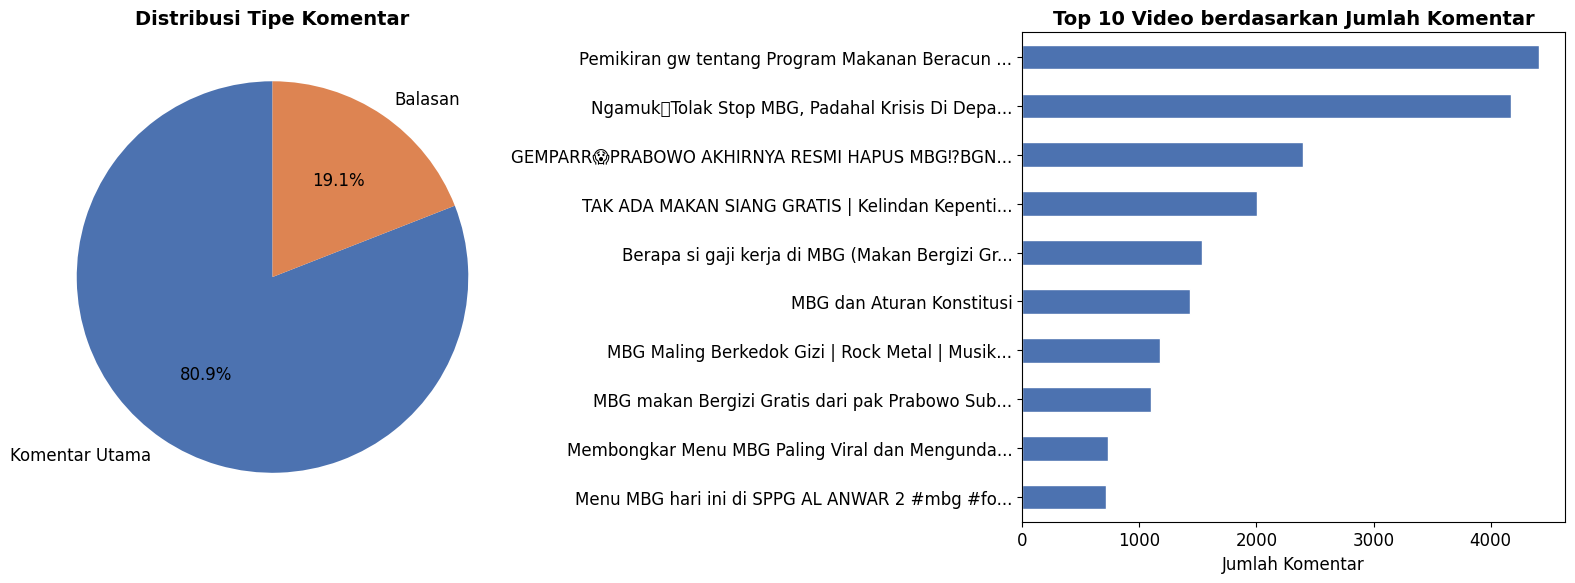

✅ Grafik disimpan di outputs/figures/eda_distribusi.png


In [4]:
# ============================================================
# EDA — VISUALISASI DISTRIBUSI
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Distribusi Tipe Komentar ---
tipe_counts = df['Tipe Komentar'].value_counts()
axes[0].pie(
    tipe_counts.values,
    labels=tipe_counts.index,
    autopct='%1.1f%%',
    colors=['#4C72B0', '#DD8452'],
    startangle=90
)
axes[0].set_title('Distribusi Tipe Komentar', fontweight='bold', fontsize=14)

# --- Plot 2: Top 10 Video Paling Banyak Komentar ---
top_videos = df.groupby('Judul Video').size().nlargest(10)
# Potong judul panjang agar rapi
top_videos.index = [t[:45] + '...' if len(t) > 45 else t for t in top_videos.index]
top_videos.sort_values().plot(
    kind='barh', ax=axes[1],
    color='#4C72B0', edgecolor='white'
)
axes[1].set_title('Top 10 Video berdasarkan Jumlah Komentar', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Jumlah Komentar')

plt.tight_layout()
plt.savefig('../outputs/figures/eda_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik disimpan di outputs/figures/eda_distribusi.png')

--- Statistik Panjang Komentar ---
count    22929.00
mean        93.53
std        161.80
min          1.00
25%         29.00
50%         56.00
75%        108.00
max       6276.00
Name: panjang_komentar, dtype: float64


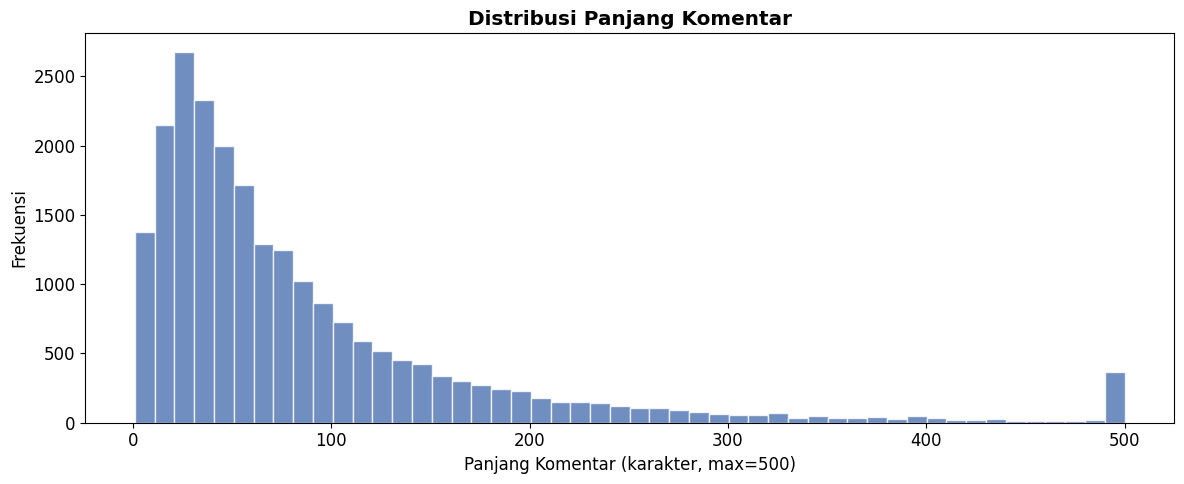

In [5]:
# ============================================================
# EDA — DISTRIBUSI PANJANG KOMENTAR
# ============================================================

# Hitung panjang karakter setiap komentar
df['panjang_komentar'] = df['Komentar'].astype(str).apply(len)

print('--- Statistik Panjang Komentar ---')
print(df['panjang_komentar'].describe().round(2))

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(
    df['panjang_komentar'].clip(upper=500),  # clip agar skala lebih baik
    bins=50, color='#4C72B0', edgecolor='white', alpha=0.8
)
ax.set_xlabel('Panjang Komentar (karakter, max=500)')
ax.set_ylabel('Frekuensi')
ax.set_title('Distribusi Panjang Komentar', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/eda_panjang_komentar.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🎯 STEP 3 — Feature Selection

> Dari 8 kolom yang ada, kita **hanya butuh kolom `Komentar`** sebagai fitur utama untuk analisis sentimen. Kolom lain bisa dipertahankan sebagai metadata tapi tidak masuk ke model ML.
>
> Ini seperti dalam catur: tidak semua bidak perlu aktif — tentukan bidak mana yang paling strategis untuk posisimu saat ini.

In [6]:
# ============================================================
# STEP 3: FEATURE SELECTION
# ============================================================

# Kolom yang akan kita gunakan
FITUR_UTAMA = 'Komentar'       # input teks untuk model
META_COLS   = ['Video ID', 'Judul Video', 'Tipe Komentar', 'Author', 'Tanggal Komentar']

# Buat dataframe kerja (copy agar tidak merusak data asli)
df_work = df[META_COLS + [FITUR_UTAMA]].copy()

print('✅ Kolom yang digunakan dalam analisis:')
for col in df_work.columns:
    print(f'   • {col}')

print(f'\n   Total data: {len(df_work):,} komentar')
df_work.head(3)

✅ Kolom yang digunakan dalam analisis:
   • Video ID
   • Judul Video
   • Tipe Komentar
   • Author
   • Tanggal Komentar
   • Komentar

   Total data: 22,929 komentar


,Video ID,Judul Video,Tipe Komentar,Author,Tanggal Komentar,Komentar
0,LsyTtfdBmRE,MBG Maling Berkedok Gizi | Rock Metal | Musik ...,Komentar Utama,@GitarisGadungan2,2026-05-11T10:14:12Z,⚠️ *DISCLAIMER* ⚠️\n*Video ini dibuat dengan b...
1,LsyTtfdBmRE,MBG Maling Berkedok Gizi | Rock Metal | Musik ...,Komentar Utama,@rakyatbersatu-m1q,2026-05-12T14:52:02Z,Periksa oknum Maling\nBangsat \nGarong\nYg mer...
2,LsyTtfdBmRE,MBG Maling Berkedok Gizi | Rock Metal | Musik ...,Komentar Utama,@VicoManuputty,2026-05-10T14:39:57Z,MUSIK NYANYIAN TABRAK TEMBOK SUSNAN BATU BAT...


---
## 🧹 STEP 4 — Data Cleaning

> **Data Cleaning** adalah proses menghapus 'noise' dari teks: URL, mention (@username), hashtag, emoji, HTML entities, angka, dan tanda baca. Tanpa tahap ini, model akan belajar dari 'sampah' dan hasilnya tidak akurat.
>
> **Library yang digunakan:** `re` (Regular Expression) — library bawaan Python untuk pencocokan pola teks.

In [7]:
# ============================================================
# STEP 4: DATA CLEANING
# ============================================================

def clean_text(text):
    """
    Membersihkan teks dari semua noise:
    URL, mention, hashtag, HTML entities, emoji, angka, tanda baca.
    Setiap baris regex memiliki tujuan spesifik.
    """
    if not isinstance(text, str):
        return ""  # tangani nilai non-string (NaN, float, dll)
    
    text = re.sub(r'http\S+|www\.\S+', ' ', text)      # (1) hapus URL
    text = re.sub(r'@[\w]+', ' ', text)                 # (2) hapus @mention
    text = re.sub(r'#[\w]+', ' ', text)                 # (3) hapus #hashtag
    text = re.sub(r'&[a-zA-Z]+;', ' ', text)            # (4) hapus HTML entities (&amp; &lt; dll)
    text = re.sub(r'[^\w\s]', ' ', text)                # (5) hapus tanda baca & karakter khusus
    text = re.sub(r'\d+', ' ', text)                    # (6) hapus angka
    # (7) hapus emoji (unicode range emoji)
    text = re.sub(r'[\U00010000-\U0010ffff]', ' ', text, flags=re.UNICODE)
    text = re.sub(r'\s+', ' ', text).strip()            # (8) normalize whitespace berlebih
    
    return text

# Hapus duplikat dulu
n_before = len(df_work)
df_work.drop_duplicates(subset=[FITUR_UTAMA], inplace=True)
n_after = len(df_work)
print(f'🗑️  Duplikat dihapus: {n_before - n_after} baris ({n_before:,} → {n_after:,})')

# Hapus komentar kosong atau sangat pendek (< 3 karakter)
df_work = df_work[df_work[FITUR_UTAMA].astype(str).str.strip().str.len() >= 3]
print(f'🗑️  Komentar sangat pendek dihapus → sisa: {len(df_work):,}')

# Terapkan cleaning
print('\n⏳ Proses cleaning teks...')
df_work['komentar_clean'] = df_work[FITUR_UTAMA].progress_apply(clean_text)

# Hapus baris yang setelah cleaning jadi kosong
df_work = df_work[df_work['komentar_clean'].str.strip().str.len() > 2]

print(f'\n✅ Cleaning selesai! Total data bersih: {len(df_work):,}')
print('\nContoh hasil cleaning:')
for _, row in df_work.sample(3, random_state=42).iterrows():
    print(f'  BEFORE: {str(row[FITUR_UTAMA])[:80]}')
    print(f'  AFTER : {row["komentar_clean"][:80]}')
    print()

🗑️  Duplikat dihapus: 849 baris (22,929 → 22,080)
🗑️  Komentar sangat pendek dihapus → sisa: 21,992

⏳ Proses cleaning teks...


100%|██████████| 21992/21992 [00:01<00:00, 16746.91it/s]


✅ Cleaning selesai! Total data bersih: 21,657

Contoh hasil cleaning:
  BEFORE: Mat lebaran Pak Bowo.saat lebaran rata kasusampah numpuk dimanja.pegawai PPSU di
  AFTER : Mat lebaran Pak Bowo saat lebaran rata kasusampah numpuk dimanja pegawai PPSU di

  BEFORE: Sudah tau coq
  AFTER : Sudah tau coq

  BEFORE: iya ga di korupsi sma oknum2 pejabat tpi di korupsi sma org tua nya sndri..
ga s
  AFTER : iya ga di korupsi sma oknum pejabat tpi di korupsi sma org tua nya sndri ga smua



---
## 🔡 STEP 5 — Case Folding

> **Case Folding** = konversi semua huruf ke huruf kecil (lowercase). Tujuannya: agar kata `"Prabowo"`, `"prabowo"`, `"PRABOWO"` dianggap sebagai token yang **sama** oleh model.
>
> Sederhana tapi krusial — tanpa ini, vocabulary model akan membengkak secara tidak perlu.

In [8]:
# ============================================================
# STEP 5: CASE FOLDING
# ============================================================

df_work['komentar_lower'] = df_work['komentar_clean'].str.lower()

print('✅ Case Folding selesai!')
print('\nContoh:')
sample = df_work.sample(2, random_state=1)
for _, row in sample.iterrows():
    print(f'  clean : {row["komentar_clean"][:70]}')
    print(f'  lower : {row["komentar_lower"][:70]}')
    print()

✅ Case Folding selesai!

Contoh:
  clean : Ternyata udah hampir setahun ya MBG ini di Kab Pacitan ada kecamatan y
  lower : ternyata udah hampir setahun ya mbg ini di kab pacitan ada kecamatan y

  clean : Udahh pa mendingan d stop z MBG g usahh gengsi MBG malahan sarang koru
  lower : udahh pa mendingan d stop z mbg g usahh gengsi mbg malahan sarang koru



---
## ✂️ STEP 6 — Tokenizing

> **Tokenizing** = memecah satu string teks menjadi list berisi kata-kata (token) individual.
>
> Contoh: `"makan bergizi gratis"` → `['makan', 'bergizi', 'gratis']`
>
> **Library:** `nltk.tokenize.word_tokenize` — salah satu tokenizer paling reliable untuk teks bahasa Indonesia.

In [9]:
# ============================================================
# STEP 6: TOKENIZING
# ============================================================

print('⏳ Proses tokenizing...')
df_work['tokens'] = df_work['komentar_lower'].progress_apply(word_tokenize)

print('✅ Tokenizing selesai!')
print('\nContoh hasil tokenizing:')
for _, row in df_work.sample(3, random_state=7).iterrows():
    print(f'  Input : {row["komentar_lower"][:70]}')
    print(f'  Tokens: {row["tokens"][:10]} (total: {len(row["tokens"])} token)')
    print()

# Statistik token
df_work['n_tokens'] = df_work['tokens'].apply(len)
print(f'Rata-rata token per komentar: {df_work["n_tokens"].mean():.1f}')
print(f'Maksimum token             : {df_work["n_tokens"].max()}')

⏳ Proses tokenizing...


100%|██████████| 21657/21657 [00:05<00:00, 3677.14it/s]

✅ Tokenizing selesai!

Contoh hasil tokenizing:
  Input : yg dapet dapet dari prgram ini pasti ingin terus rakyat yg nanggung ha
  Tokens: ['yg', 'dapet', 'dapet', 'dari', 'prgram', 'ini', 'pasti', 'ingin', 'terus', 'rakyat'] (total: 34 token)

  Input : dibtempat sy cuci puring mbg gaji bln juta
  Tokens: ['dibtempat', 'sy', 'cuci', 'puring', 'mbg', 'gaji', 'bln', 'juta'] (total: 8 token)

  Input : mbg ditutup gaji naik sembako naik haji juga udah naik
  Tokens: ['mbg', 'ditutup', 'gaji', 'naik', 'sembako', 'naik', 'haji', 'juga', 'udah', 'naik'] (total: 10 token)

Rata-rata token per komentar: 15.0
Maksimum token             : 848


---
## 🚫 STEP 7 — Stopword Removal

> **Stopword** = kata-kata umum yang tidak membawa makna sentimen, seperti: `'yang', 'di', 'ke', 'dan', 'itu', 'ini', 'dari', 'adalah'`.
>
> Menghapus stopword akan membuat model fokus pada kata-kata **bermakna** saja.
>
> **Library:** `PySastrawi` — library NLP khusus Bahasa Indonesia yang berisi daftar stopwords Indonesia.

In [10]:
# ============================================================
# STEP 7: STOPWORD REMOVAL
# ============================================================

# Inisialisasi Sastrawi Stopword
stop_factory = StopWordRemoverFactory()
stopwords_id = set(stop_factory.get_stop_words())

# Tambah custom stopwords yang relevan dengan konteks MBG
custom_stopwords = {
    'mbg', 'yg', 'nya', 'lah', 'kah', 'sih', 'nih', 'deh',
    'aja', 'dong', 'ah', 'oh', 'eh', 'ya', 'ga', 'gak',
    'nggak', 'juga', 'kalo', 'kalau', 'bisa', 'buat'
}
stopwords_id.update(custom_stopwords)

def remove_stopwords(tokens):
    """
    Filter token: hanya simpan yang bukan stopword
    dan memiliki panjang > 1 karakter.
    """
    return [t for t in tokens if t not in stopwords_id and len(t) > 1]

print(f'📚 Total stopwords (Sastrawi + custom): {len(stopwords_id)}')
print(f'   Contoh: {list(stopwords_id)[:10]}')
print()
print('⏳ Proses stopword removal...')
df_work['tokens_clean'] = df_work['tokens'].progress_apply(remove_stopwords)

print('\n✅ Stopword removal selesai!')
print('Contoh:')
for _, row in df_work.sample(3, random_state=9).iterrows():
    print(f'  Sebelum ({len(row["tokens"])} token)  : {row["tokens"][:8]}')
    print(f'  Sesudah ({len(row["tokens_clean"])} token)  : {row["tokens_clean"][:8]}')
    print()

📚 Total stopwords (Sastrawi + custom): 823
   Contoh: ['berkata', 'ia', 'dari', 'tambah', 'diperbuat', 'teringat', 'hendaklah', 'cara', 'berlangsung', 'jauh']

⏳ Proses stopword removal...


100%|██████████| 21657/21657 [00:00<00:00, 51833.98it/s]


✅ Stopword removal selesai!
Contoh:
  Sebelum (4 token)  : ['tapi', 'di', 'sekolahku', 'gagitu']
  Sesudah (2 token)  : ['sekolahku', 'gagitu']

  Sebelum (5 token)  : ['tikus', 'yang', 'mulai', 'bergerak', 'bang']
  Sesudah (3 token)  : ['tikus', 'bergerak', 'bang']

  Sebelum (3 token)  : ['program', 'proyek', 'ampas']
  Sesudah (3 token)  : ['program', 'proyek', 'ampas']



---
## 🌱 STEP 8 — Stemming

> **Stemming** = mengubah kata ke bentuk dasarnya (akar kata). Contoh:
> - `'memberikan'` → `'beri'`
> - `'kecaman'` → `'caman'` (hasil stemming, bukan selalu sempurna)
> - `'dihentikan'` → `'henti'`
>
> Tujuannya: menyamakan variasi kata yang sama akar katanya, sehingga vocabulary lebih ringkas.
>
> **Library:** `PySastrawi StemmerFactory` — stemmer Bahasa Indonesia paling populer.
>
> ⚠️ **Catatan:** Stemming memakan waktu cukup lama untuk dataset besar. Bersabar ya Dimas! ☕

In [11]:
# ============================================================
# STEP 8: STEMMING
# ============================================================

# Inisialisasi Stemmer Sastrawi
stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

def stem_tokens(tokens):
    """Stem setiap token dalam list, lalu gabung kembali jadi string."""
    return [stemmer.stem(token) for token in tokens]

print('⏳ Proses stemming... (ini memerlukan beberapa menit untuk 20K+ data)')
df_work['tokens_stemmed'] = df_work['tokens_clean'].progress_apply(stem_tokens)

# Gabungkan token hasil stemming menjadi string (siap untuk TF-IDF)
df_work['teks_final'] = df_work['tokens_stemmed'].apply(lambda x: ' '.join(x))

print('\n✅ Stemming selesai!')
print('\nContoh hasil akhir preprocessing:')
sample_cols = ['Komentar', 'teks_final']
for _, row in df_work.sample(4, random_state=42).iterrows():
    print(f'  ORIGINAL : {str(row["Komentar"])[:80]}')
    print(f'  FINAL    : {row["teks_final"][:80]}')
    print()

# Simpan hasil preprocessing
df_work.to_csv('../data/processed/dataset_preprocessed.csv', index=False)
print('💾 Data preprocessed disimpan ke data/processed/dataset_preprocessed.csv')

⏳ Proses stemming... (ini memerlukan beberapa menit untuk 20K+ data)


100%|██████████| 21657/21657 [00:14<00:00, 1533.27it/s]



✅ Stemming selesai!

Contoh hasil akhir preprocessing:
  ORIGINAL : Mat lebaran Pak Bowo.saat lebaran rata kasusampah numpuk dimanja.pegawai PPSU di
  FINAL    : mat lebaran bowo lebaran rata kasusampah numpuk manja pegawai ppsu daya gaji ged

  ORIGINAL : Sudah tau coq
  FINAL    : tau coq

  ORIGINAL : iya ga di korupsi sma oknum2 pejabat tpi di korupsi sma org tua nya sndri..
ga s
  FINAL    : iya korupsi sma oknum jabat tpi korupsi sma org tua sndri smua org tua salah utk

  ORIGINAL : Bagus lah kalou mbg di tu2p di ganti pendidikan dan kesehatan geratis
  FINAL    : bagus kalou tu ganti didik sehat gerat

💾 Data preprocessed disimpan ke data/processed/dataset_preprocessed.csv


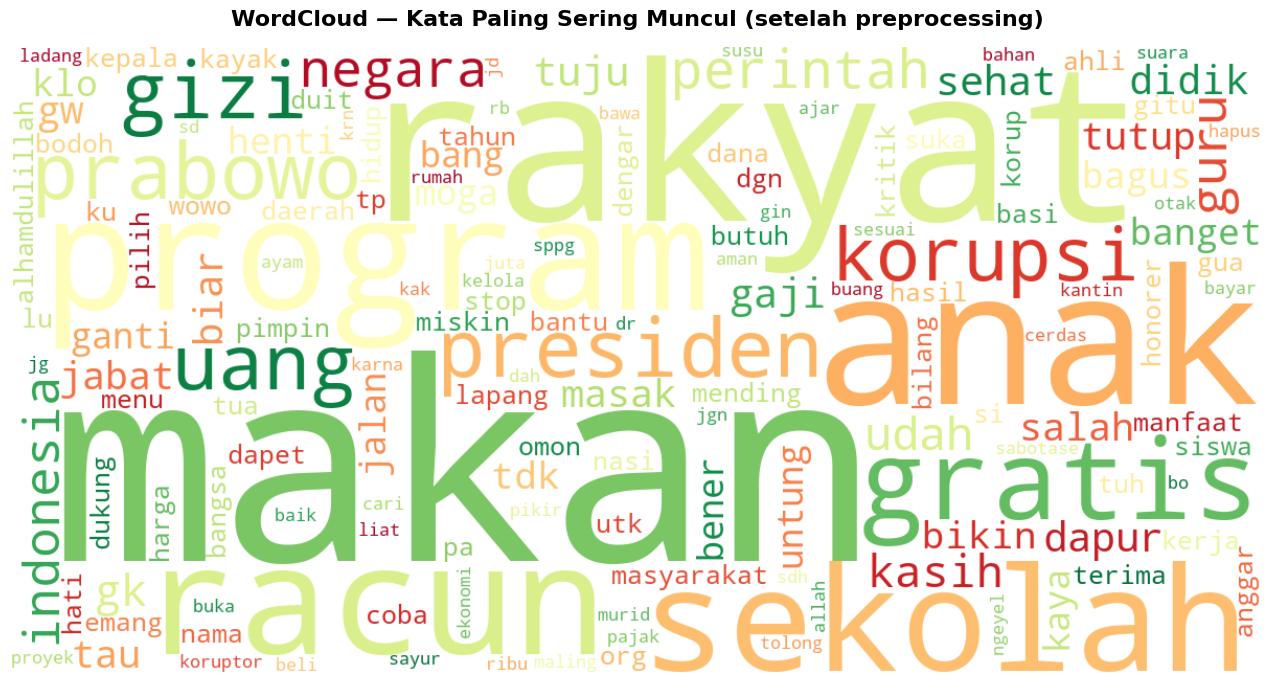

✅ WordCloud disimpan!


In [13]:
# ============================================================
# VISUALISASI — WORDCLOUD SETELAH PREPROCESSING
# ============================================================

all_words = ' '.join(df_work['teks_final'].dropna())

wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='RdYlGn',
    max_words=150,
    collocations=False
).generate(all_words)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud — Kata Paling Sering Muncul (setelah preprocessing)', 
        fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../outputs/figures/wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ WordCloud disimpan!')

---
## 🤖 STEP 9 — Auto-Labeling dengan IndoBERT

> Karena dataset kita **belum memiliki label sentimen**, kita gunakan **IndoBERT** — model transformer yang sudah di-train pada teks Bahasa Indonesia — untuk memberikan label otomatis: **Positif, Negatif, atau Netral**.
>
> **Model yang digunakan:** `mdhugol/indonesia-bert-sentiment-classifier`
>
> Label yang dihasilkan:
> - **LABEL_0** → Negatif
> - **LABEL_1** → Netral  
> - **LABEL_2** → Positif
>
> ⚠️ Proses ini **bisa memakan waktu lama** (tergantung GPU/CPU). Kita proses dalam batch dan simpan hasilnya.
>
> ⚠️ Pastikan koneksi internet aktif untuk download model pertama kali (~400MB).

In [15]:
# ============================================================
# STEP 9: AUTO-LABELING DENGAN IndoBERT (RoBERTa - Public Model)
# Model: w11wo/indonesian-roberta-base-sentiment-classifier
# ============================================================

LABELED_PATH = '../data/processed/dataset_labeled.csv'

# === CEK: jika sudah pernah dilabeli, skip proses ini ===
if os.path.exists(LABELED_PATH):
    print('📂 File labeled sudah ada! Loading dari cache...')
    df_labeled = pd.read_csv(LABELED_PATH)
    print(f'✅ Dataset labeled dimuat: {len(df_labeled):,} baris')
    print(df_labeled['sentimen'].value_counts())

else:
    print('⏳ Memuat model... (download ~500MB pertama kali, sabar ya ☕)')

    # ✅ GANTI MODEL: public model, tidak butuh login HuggingFace
    MODEL_NAME = 'w11wo/indonesian-roberta-base-sentiment-classifier'

    sentiment_pipeline = pipeline(
        task='text-classification',
        model=MODEL_NAME,
        tokenizer=MODEL_NAME,
        truncation=True,      # otomatis truncate jika teks > 512 token
        max_length=512,
        # device=0            # Uncomment jika punya GPU CUDA
    )

    # ✅ GANTI LABEL_MAP: model ini output-nya lowercase
    LABEL_MAP = {
        'positive': 'Positif',
        'neutral' : 'Netral',
        'negative': 'Negatif'
    }

    def get_sentiment(text):
        """
        Prediksi sentimen satu teks.
        Model RoBERTa ini mengembalikan label lowercase:
        'positive', 'neutral', 'negative'
        """
        try:
            result = sentiment_pipeline(str(text))[0]
            label_raw = result['label'].lower()  # ✅ lowercase dulu sebelum mapping
            return LABEL_MAP.get(label_raw, 'Netral'), round(result['score'], 4)
        except Exception:
            return 'Netral', 0.0

    # Gunakan teks komentar_lower (sebelum stemming) untuk transformer
    # Alasan: BERT/RoBERTa lebih akurat pada teks natural, bukan hasil stemming
    print('\n⏳ Proses labeling sentimen... (untuk 20K data bisa 30-60 menit)')
    print('   Tips: tinggalkan saja dulu, kerjakan hal lain sambil nunggu ☕\n')

    results = []
    BATCH = 32  # ✅ Dikecilkan dari 64 → 32 agar lebih stabil di CPU
    texts = df_work['komentar_lower'].tolist()

    for i in tqdm(range(0, len(texts), BATCH), desc='Labeling Sentimen'):
        batch = [str(t)[:512] for t in texts[i:i+BATCH]]
        try:
            preds = sentiment_pipeline(batch)
            for p in preds:
                label_raw = p['label'].lower()  # ✅ lowercase sebelum mapping
                results.append((
                    LABEL_MAP.get(label_raw, 'Netral'),
                    round(p['score'], 4)
                ))
        except Exception as e:
            # Jika satu batch error, isi dengan Netral dan lanjut
            print(f'   ⚠️ Batch {i} error: {e} — diisi Netral')
            results.extend([('Netral', 0.0)] * len(batch))

    df_work['sentimen']       = [r[0] for r in results]
    df_work['sentimen_score'] = [r[1] for r in results]

    df_labeled = df_work.copy()
    df_labeled.to_csv(LABELED_PATH, index=False)
    print(f'\n💾 Dataset labeled disimpan ke {LABELED_PATH}')

    print('\n📊 Distribusi Sentimen Hasil Labeling:')
    print(df_labeled['sentimen'].value_counts())
    print(f'\nTotal labeled: {len(df_labeled):,} komentar')

⏳ Memuat model... (download ~500MB pertama kali, sabar ya ☕)


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]


⏳ Proses labeling sentimen... (untuk 20K data bisa 30-60 menit)
   Tips: tinggalkan saja dulu, kerjakan hal lain sambil nunggu ☕



Labeling Sentimen: 100%|██████████| 677/677 [46:41<00:00,  4.14s/it] 



💾 Dataset labeled disimpan ke ../data/processed/dataset_labeled.csv

📊 Distribusi Sentimen Hasil Labeling:
sentimen
Negatif    14270
Positif     3825
Netral      3562
Name: count, dtype: int64

Total labeled: 21,657 komentar


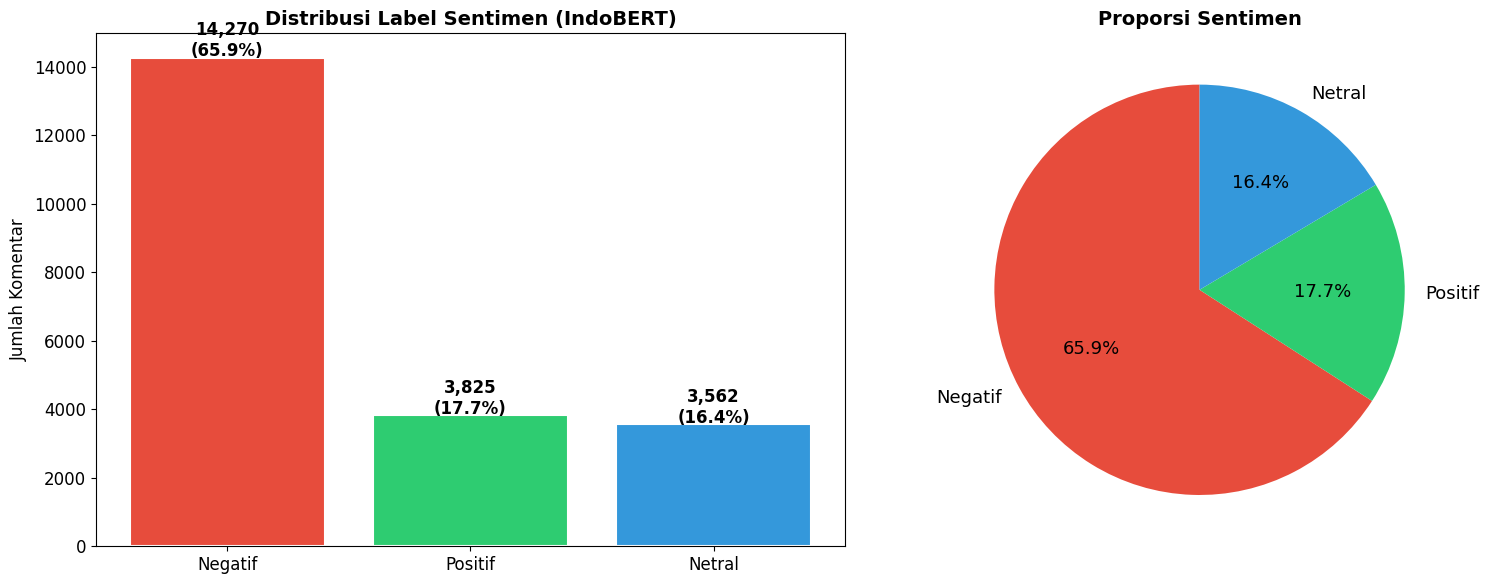

✅ Visualisasi sentimen disimpan!


In [16]:
# ============================================================
# VISUALISASI DISTRIBUSI SENTIMEN
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Warna per sentimen
color_map = {'Positif': '#2ecc71', 'Netral': '#3498db', 'Negatif': '#e74c3c'}
sent_counts = df_labeled['sentimen'].value_counts()
colors = [color_map.get(s, 'gray') for s in sent_counts.index]

# Bar chart
axes[0].bar(sent_counts.index, sent_counts.values, color=colors, edgecolor='white', linewidth=1.5)
for i, (label, val) in enumerate(zip(sent_counts.index, sent_counts.values)):
    axes[0].text(i, val + 50, f'{val:,}\n({val/len(df_labeled)*100:.1f}%)', 
                 ha='center', fontweight='bold')
axes[0].set_title('Distribusi Label Sentimen (IndoBERT)', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Jumlah Komentar')

# Pie chart
axes[1].pie(sent_counts.values, labels=sent_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 13})
axes[1].set_title('Proporsi Sentimen', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('../outputs/figures/distribusi_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisasi sentimen disimpan!')

---
## 🔢 STEP 10 — Encoding Label

> **Encoding** = konversi label teks menjadi angka, karena algoritma ML hanya bisa memproses angka.
>
> `Negatif → 0`, `Netral → 1`, `Positif → 2`
>
> **Library:** `sklearn.preprocessing.LabelEncoder` — standard encoding dari scikit-learn.

In [17]:
# ============================================================
# STEP 10: ENCODING LABEL
# ============================================================

le = LabelEncoder()
df_labeled['label_encoded'] = le.fit_transform(df_labeled['sentimen'])

print('✅ Label Encoding selesai!')
print('\nMapping label:')
for label, code in zip(le.classes_, range(len(le.classes_))):
    print(f'   {label} → {code}')

# Simpan label encoder untuk deployment nanti
joblib.dump(le, '../models/label_encoder.pkl')
print('\n💾 Label encoder disimpan ke models/label_encoder.pkl')

print('\nSample data dengan encoding:')
df_labeled[['Komentar', 'sentimen', 'label_encoded']].sample(5, random_state=42)

✅ Label Encoding selesai!

Mapping label:
   Negatif → 0
   Netral → 1
   Positif → 2

💾 Label encoder disimpan ke models/label_encoder.pkl

Sample data dengan encoding:


,Komentar,sentimen,label_encoded
15581,Mat lebaran Pak Bowo.saat lebaran rata kasusam...,Negatif,0
17396,Sudah tau coq,Negatif,0
4580,iya ga di korupsi sma oknum2 pejabat tpi di ko...,Negatif,0
11138,Bagus lah kalou mbg di tu2p di ganti pendidika...,Negatif,0
3547,Tapi Di SD Gue Gak Tu Keracunan Biasa Aja Mala...,Positif,2


---
## 🏗️ STEP 11 — Membangun Pipeline Model

> Kita akan membandingkan **4 algoritma ML** menggunakan **TF-IDF** sebagai feature extractor:
>
> | Model | Kelebihan | Kekurangan |
> |-------|-----------|------------|
> | **Logistic Regression** | Cepat, interpretable | Asumsi linearitas |
> | **Naive Bayes** | Sangat cepat, bagus untuk teks | Asumsi independensi fitur |
> | **Random Forest** | Robust, non-linear | Lambat, black-box |
> | **SVM (LinearSVC)** | Akurat untuk teks, efisien | Perlu tuning kernel |
>
> **TF-IDF** (Term Frequency-Inverse Document Frequency) = representasi numerik teks yang menimbang kata berdasarkan seberapa penting kata tersebut dalam dokumen relative terhadap seluruh corpus.
>
> Ini seperti memilih 4 opening berbeda dalam catur lalu membandingkan mana yang paling efektif untuk kondisi ini! ♟️

In [18]:
# ============================================================
# STEP 11: MEMBANGUN PIPELINE MODEL
# ============================================================

# === Persiapan Data ===
# Gunakan teks_final (hasil stemming) sebagai fitur
# Filter baris yang teks_final-nya tidak kosong
df_model = df_labeled[df_labeled['teks_final'].notna() & (df_labeled['teks_final'].str.strip() != '')].copy()

X = df_model['teks_final']
y = df_model['label_encoded']

print(f'📊 Data untuk modeling:')
print(f'   Total sampel  : {len(X):,}')
print(f'   Distribusi label: {dict(zip(le.classes_, np.bincount(y)))}')

# === Train-Test Split (80:20) ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # pastikan distribusi kelas proporsional di train & test
)

print(f'\n✅ Split data:')
print(f'   Train : {len(X_train):,} sampel (80%)')
print(f'   Test  : {len(X_test):,} sampel (20%)')

# === Definisi Pipeline Model ===
# Setiap pipeline = TF-IDF Vectorizer + Classifier
# Keduanya dirangkai dalam satu objek Pipeline agar mudah digunakan

models = {
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=10000,   # max 10K kata dalam vocabulary
            ngram_range=(1, 2),   # unigram + bigram
            min_df=2              # abaikan kata yang muncul < 2x
        )),
        ('clf', LogisticRegression(
            max_iter=1000,
            random_state=42,
            class_weight='balanced'  # tangani imbalanced class
        ))
    ]),

    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=10000,
            ngram_range=(1, 2),
            min_df=2
        )),
        ('clf', MultinomialNB(
            alpha=1.0  # Laplace smoothing
        ))
    ]),

    'Random Forest': Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=5000,  # lebih sedikit karena RF lebih berat
            ngram_range=(1, 1),
            min_df=2
        )),
        ('clf', RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1,             # gunakan semua core CPU
            class_weight='balanced'
        ))
    ]),

    'SVM (LinearSVC)': Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=10000,
            ngram_range=(1, 2),
            min_df=2
        )),
        ('clf', LinearSVC(
            max_iter=2000,
            random_state=42,
            class_weight='balanced'
        ))
    ])
}

print(f'\n✅ {len(models)} model pipeline siap di-training!')

📊 Data untuk modeling:
   Total sampel  : 21,393
   Distribusi label: {'Negatif': np.int64(14160), 'Netral': np.int64(3435), 'Positif': np.int64(3798)}

✅ Split data:
   Train : 17,114 sampel (80%)
   Test  : 4,279 sampel (20%)

✅ 4 model pipeline siap di-training!


---
## 📊 STEP 12 — Training & Evaluasi Model

> Kita latih semua model dan evaluasi menggunakan:
> - **Accuracy** — persentase prediksi benar dari total
> - **Precision** — dari yang diprediksi positif, berapa yang benar positif
> - **Recall** — dari yang benar positif, berapa yang berhasil ditemukan
> - **F1-Score** — harmonic mean of Precision & Recall (metric paling penting untuk imbalanced dataset)
> - **Confusion Matrix** — visualisasi kesalahan prediksi per kelas

In [19]:
# ============================================================
# STEP 12: TRAINING & EVALUASI SEMUA MODEL
# ============================================================

results_summary = []
trained_models = {}

for name, pipeline_model in models.items():
    print(f'\n⏳ Training: {name}...')
    
    # Training
    pipeline_model.fit(X_train, y_train)
    
    # Prediksi
    y_pred = pipeline_model.predict(X_test)
    
    # Hitung metrik
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')
    
    results_summary.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'F1-Score (weighted)': round(f1, 4)
    })
    trained_models[name] = pipeline_model
    
    print(f'   Accuracy : {acc:.4f} ({acc*100:.2f}%)')
    print(f'   F1-Score : {f1:.4f}')

# Tampilkan tabel ringkasan
df_results = pd.DataFrame(results_summary).sort_values('F1-Score (weighted)', ascending=False)
print('\n' + '='*60)
print('📊 RINGKASAN PERBANDINGAN MODEL')
print('='*60)
print(df_results.to_string(index=False))

# Simpan hasil
df_results.to_csv('../outputs/reports/hasil_evaluasi_model.csv', index=False)
print('\n💾 Hasil evaluasi disimpan ke outputs/reports/hasil_evaluasi_model.csv')

# Tentukan model terbaik
BEST_MODEL_NAME = df_results.iloc[0]['Model']
print(f'\n🏆 Model terbaik: {BEST_MODEL_NAME}')


⏳ Training: Logistic Regression...
   Accuracy : 0.6740 (67.40%)
   F1-Score : 0.6911

⏳ Training: Naive Bayes...
   Accuracy : 0.6988 (69.88%)
   F1-Score : 0.6144

⏳ Training: Random Forest...
   Accuracy : 0.7053 (70.53%)
   F1-Score : 0.6920

⏳ Training: SVM (LinearSVC)...
   Accuracy : 0.7013 (70.13%)
   F1-Score : 0.7063

📊 RINGKASAN PERBANDINGAN MODEL
              Model  Accuracy  F1-Score (weighted)
    SVM (LinearSVC)    0.7013               0.7063
      Random Forest    0.7053               0.6920
Logistic Regression    0.6740               0.6911
        Naive Bayes    0.6988               0.6144

💾 Hasil evaluasi disimpan ke outputs/reports/hasil_evaluasi_model.csv

🏆 Model terbaik: SVM (LinearSVC)


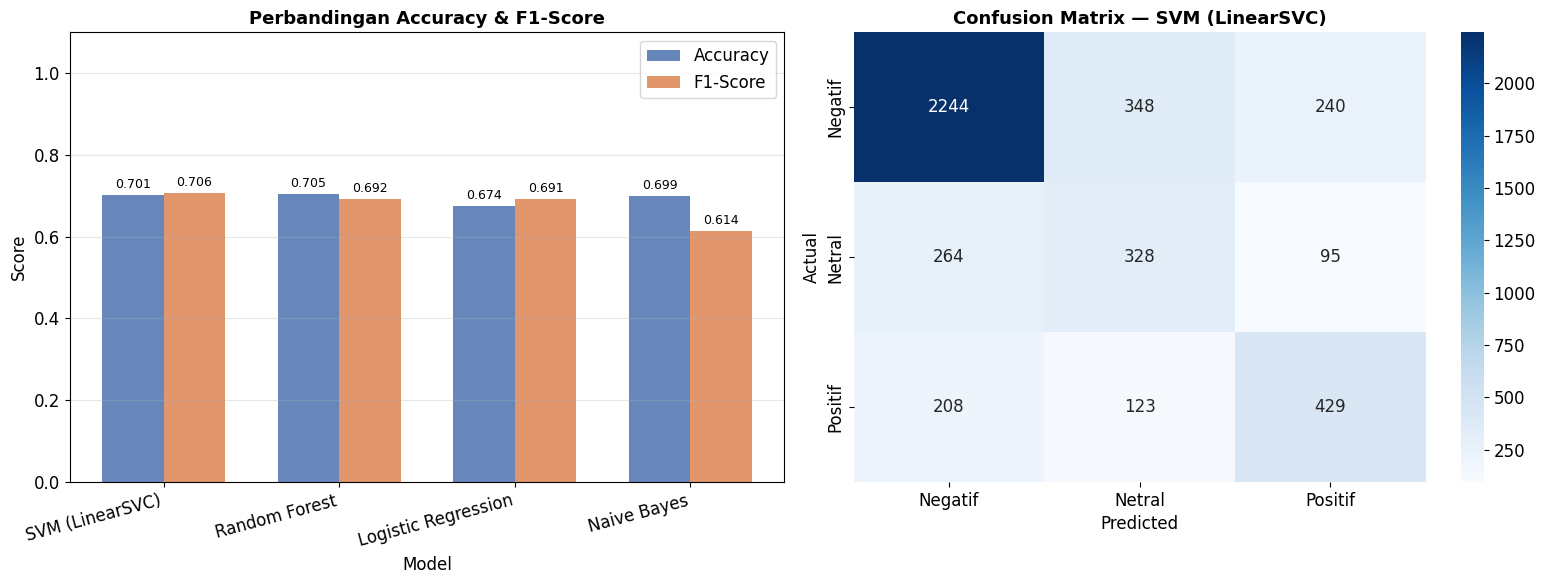


📋 Classification Report — SVM (LinearSVC):
              precision    recall  f1-score   support

     Negatif       0.83      0.79      0.81      2832
      Netral       0.41      0.48      0.44       687
     Positif       0.56      0.56      0.56       760

    accuracy                           0.70      4279
   macro avg       0.60      0.61      0.60      4279
weighted avg       0.71      0.70      0.71      4279



In [21]:
# ============================================================
# VISUALISASI EVALUASI: BAR CHART + CONFUSION MATRIX
# ============================================================

# --- Plot 1: Perbandingan Akurasi & F1 semua model ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(df_results))
width = 0.35

bars1 = axes[0].bar(x - width/2, df_results['Accuracy'], width, 
                    label='Accuracy', color='#4C72B0', alpha=0.85)
bars2 = axes[0].bar(x + width/2, df_results['F1-Score (weighted)'], width, 
                    label='F1-Score', color='#DD8452', alpha=0.85)

axes[0].set_xlabel('Model')
axes[0].set_ylabel('Score')
axes[0].set_title('Perbandingan Accuracy & F1-Score', fontweight='bold', fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_results['Model'], rotation=15, ha='right')
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Label nilai di atas bar
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

# --- Plot 2: Confusion Matrix model terbaik ---
best_model = trained_models[BEST_MODEL_NAME]
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    ax=axes[1]
)
axes[1].set_title(f'Confusion Matrix — {BEST_MODEL_NAME}', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../outputs/figures/evaluasi_model.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Classification Report Lengkap Model Terbaik ---
print(f'\n📋 Classification Report — {BEST_MODEL_NAME}:')
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

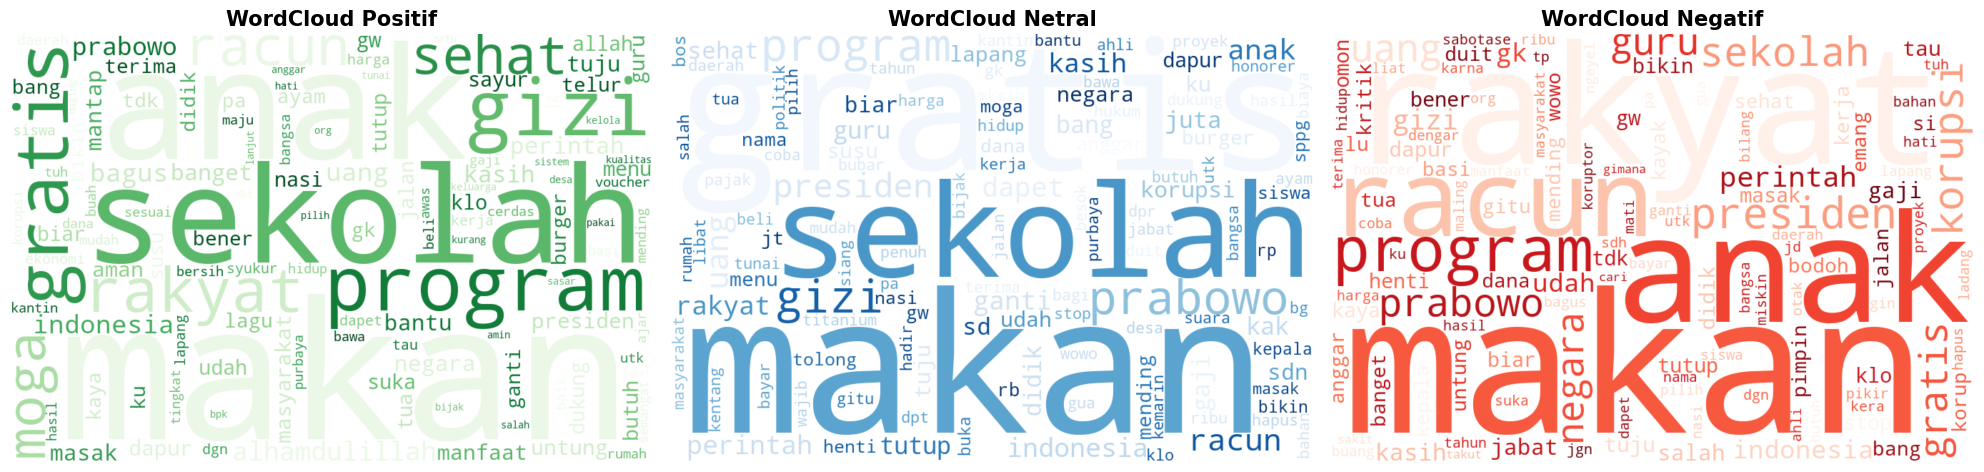

In [31]:
# ============================================================
# WORDCLOUD BERDASARKAN LABEL SENTIMEN
# ============================================================

sentiment_order = ['Positif', 'Netral', 'Negatif']

wordcloud_cmaps = {
    'Positif': 'Greens',
    'Netral': 'Blues',
    'Negatif': 'Reds'
}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, label in zip(axes, sentiment_order):
    text_by_sentiment = ' '.join(
        df_labeled.loc[df_labeled['sentimen'] == label, 'teks_final']
        .dropna()
        .astype(str)
    )

    wc = WordCloud(
        width=900,
        height=600,
        background_color='white',
        colormap=wordcloud_cmaps[label],
        max_words=120,
        collocations=False,
        random_state=42
    ).generate(text_by_sentiment)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'WordCloud {label}', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# WORDCLOUD PER MASING-MASING LABEL SENTIMEN
# ============================================================

# Setting warna untuk setiap label sentimen
sentiment_settings = {
    'Positif': {
        'colormap': 'Greens',
        'title_color': '#2ecc71'
    },
    'Netral': {
        'colormap': 'Blues',
        'title_color': '#3498db'
    },
    'Negatif': {
        'colormap': 'Reds',
        'title_color': '#e74c3c'
    }
}

for label, setting in sentiment_settings.items():
    # Ambil teks berdasarkan label sentimen
    teks_label = ' '.join(
        df_labeled.loc[df_labeled['sentimen'] == label, 'teks_final']
        .dropna()
        .astype(str)
    )

    if teks_label.strip() == '':
        print(f'Tidak ada teks untuk label {label}')
        continue

    # Buat WordCloud
    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color='white',
        colormap=setting['colormap'],
        max_words=150,
        collocations=False,
        random_state=42
    ).generate(teks_label)

    # Tampilkan WordCloud per label
    plt.figure(figsize=(14, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(
        f'WordCloud Sentimen {label}',
        fontsize=18,
        fontweight='bold',
        color=setting['title_color'],
        pad=15
    )
    plt.tight_layout()

    # Simpan gambar per label
    output_path = f'../outputs/figures/wordcloud_{label.lower()}.png'
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f'WordCloud sentimen {label} disimpan ke: {output_path}')



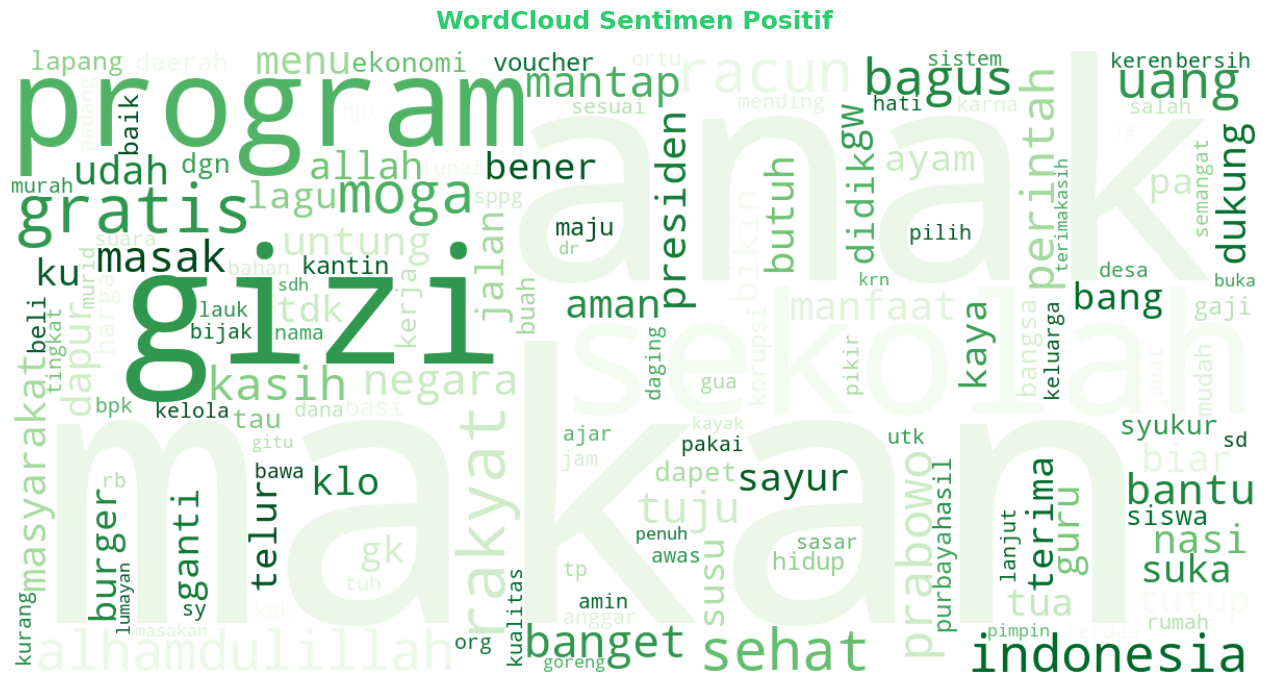

WordCloud sentimen Positif disimpan ke: ../outputs/figures/wordcloud_positif.png


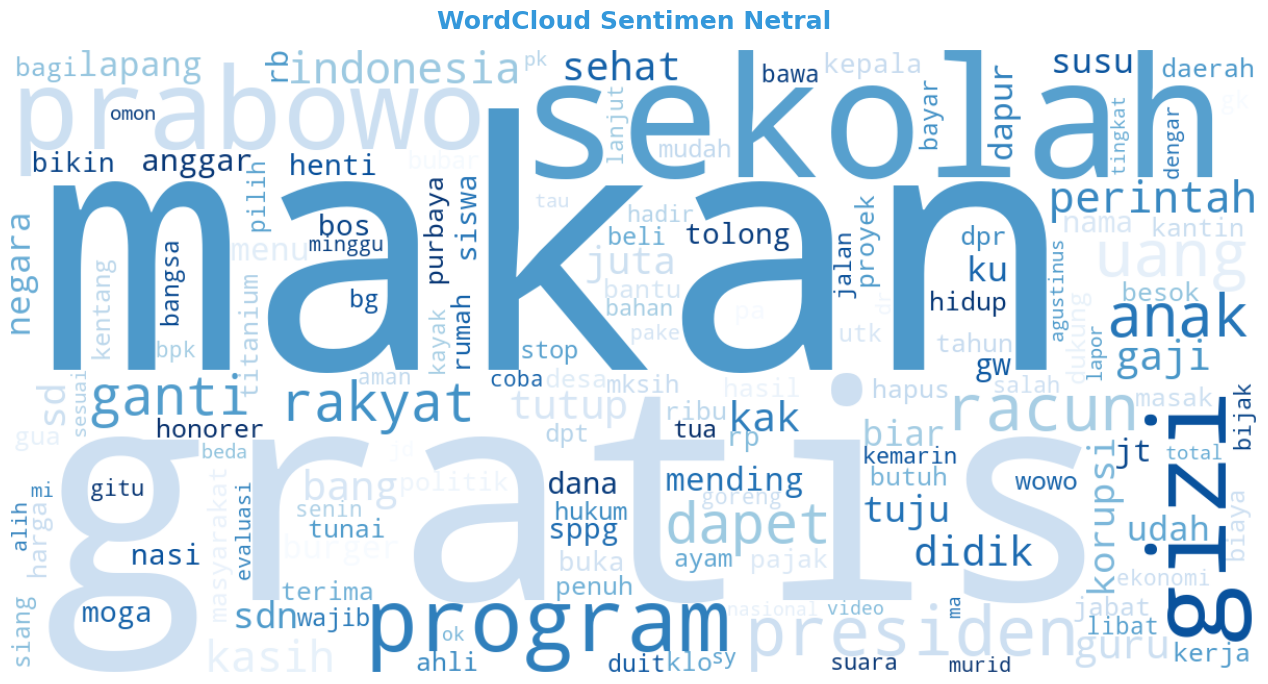

WordCloud sentimen Netral disimpan ke: ../outputs/figures/wordcloud_netral.png


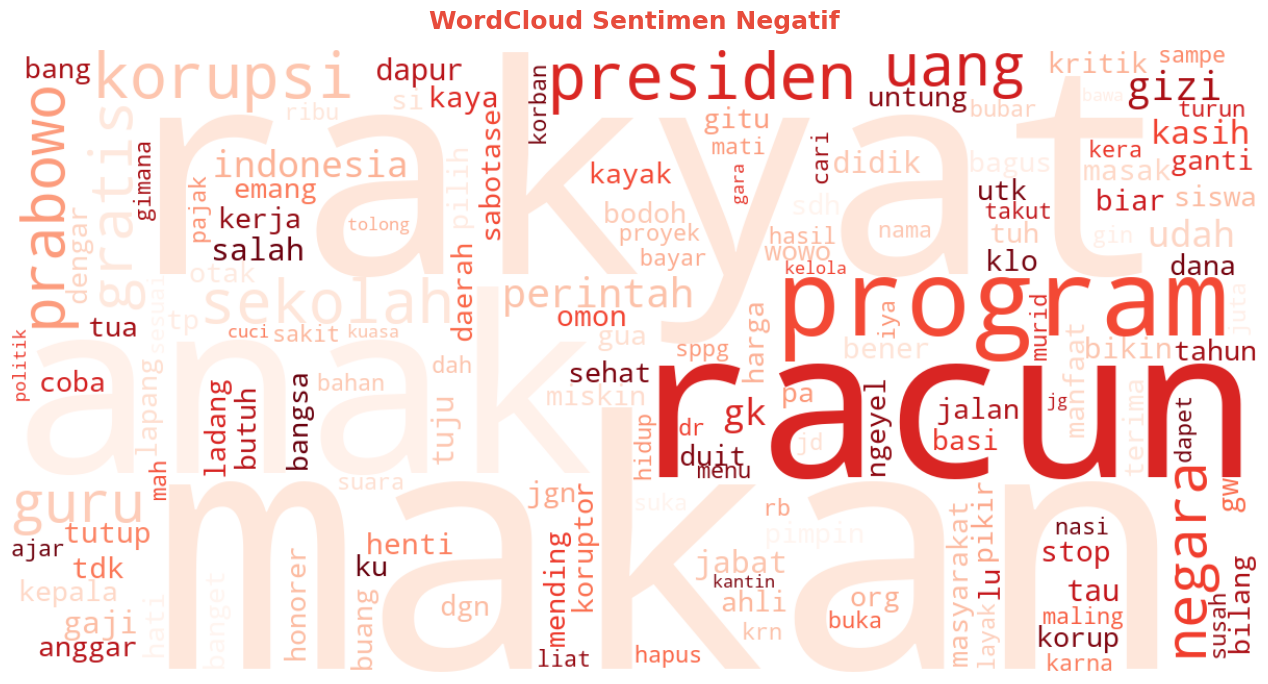

WordCloud sentimen Negatif disimpan ke: ../outputs/figures/wordcloud_negatif.png


In [32]:
# ============================================================
# WORDCLOUD PER MASING-MASING LABEL SENTIMEN
# ============================================================

# Setting warna untuk setiap label sentimen
sentiment_settings = {
    'Positif': {
        'colormap': 'Greens',
        'title_color': '#2ecc71'
    },
    'Netral': {
        'colormap': 'Blues',
        'title_color': '#3498db'
    },
    'Negatif': {
        'colormap': 'Reds',
        'title_color': '#e74c3c'
    }
}

for label, setting in sentiment_settings.items():
    teks_label = ' '.join(
        df_labeled.loc[df_labeled['sentimen'] == label, 'teks_final']
        .dropna()
        .astype(str)
    )

    if teks_label.strip() == '':
        print(f'Tidak ada teks untuk label {label}')
        continue

    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color='white',
        colormap=setting['colormap'],
        max_words=150,
        collocations=False,
        random_state=42
    ).generate(teks_label)

    plt.figure(figsize=(14, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(
        f'WordCloud Sentimen {label}',
        fontsize=18,
        fontweight='bold',
        color=setting['title_color'],
        pad=15
    )
    plt.tight_layout()

    output_path = f'../outputs/figures/wordcloud_{label.lower()}.png'
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f'WordCloud sentimen {label} disimpan ke: {output_path}')

---
## 🔮 STEP 13 — Model Prediksi

> Sekarang kita test model terbaik untuk memprediksi sentimen komentar **baru** yang belum pernah dilihat model.
>
> Ini fase 'endgame' dalam catur — kita uji apakah strategi yang telah dibangun bisa menyelesaikan masalah nyata! ♟️

In [25]:
# ============================================================
# STEP 13: FUNGSI PREDIKSI KOMENTAR BARU
# ============================================================

# Import fungsi preprocessing dari src (jika pakai struktur folder)
import sys
sys.path.append('../src')

def preprocess_for_predict(text):
    """Preprocessing teks baru sebelum diprediksi."""
    # Clean
    text = re.sub(r'http\S+|www\.\S+', ' ', str(text))
    text = re.sub(r'@[\w]+', ' ', text)
    text = re.sub(r'#[\w]+', ' ', text)
    text = re.sub(r'&[a-zA-Z]+;', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[\U00010000-\U0010ffff]', ' ', text, flags=re.UNICODE)
    text = re.sub(r'\s+', ' ', text).strip()
    # Case fold
    text = text.lower()
    # Tokenize
    tokens = word_tokenize(text)
    # Stopword removal
    tokens = [t for t in tokens if t not in stopwords_id and len(t) > 1]
    # Stemming
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)


def predict_sentiment(komentar, model=None, label_encoder=None):
    """
    Prediksi sentimen untuk satu atau lebih komentar.
    
    Args:
        komentar (str or list): teks komentar baru
        model: trained pipeline model
        label_encoder: fitted LabelEncoder
    
    Returns:
        list of dict: prediksi sentimen per komentar
    """
    if model is None:
        model = best_model
    if label_encoder is None:
        label_encoder = le
    
    if isinstance(komentar, str):
        komentar = [komentar]
    
    results = []
    for k in komentar:
        processed = preprocess_for_predict(k)
        pred_code = model.predict([processed])[0]
        pred_label = label_encoder.inverse_transform([pred_code])[0]
        results.append({
            'komentar': k,
            'teks_processed': processed,
            'sentimen': pred_label
        })
    
    return results


In [36]:
# === TEST PREDIKSI ===
komentar_baru = [
    "Mbg tuh bagus, beberapa anak yang dulunya kelaperan karna ada mbg cukup terpenuhi makanannya sekarang",
    "MBG BAGUS",
    "Prabowo bodoh"
]

print('🔮 Hasil Prediksi Sentimen Komentar Baru:')
print('='*70)
hasil = predict_sentiment(komentar_baru)
for h in hasil:
    emoji = {'Positif': '🟢', 'Netral': '🔵', 'Negatif': '🔴'}.get(h['sentimen'], '⚪')
    print(f'{emoji} [{h["sentimen"]:8s}] {h["komentar"][:70]}')

print('='*70)

🔮 Hasil Prediksi Sentimen Komentar Baru:
🔴 [Negatif ] Mbg tuh bagus, beberapa anak yang dulunya kelaperan karna ada mbg cuku
🟢 [Positif ] MBG BAGUS
🔴 [Negatif ] Prabowo bodoh


---
## 💾 STEP 14 — Deploy: Simpan Model

> **Deployment** dalam konteks ini = menyimpan model yang sudah dilatih ke file `.pkl` (pickle) menggunakan `joblib`, sehingga bisa digunakan kembali tanpa perlu melatih ulang dari awal.
>
> Format `.pkl` bisa di-load kembali dan langsung digunakan untuk prediksi — baik di Python script, Flask API, Streamlit, atau sistem lainnya.

In [23]:
# ============================================================
# STEP 14: SIMPAN MODEL (DEPLOYMENT)
# ============================================================

# Simpan SEMUA model yang telah dilatih
for name, model in trained_models.items():
    filename = name.lower().replace(' ', '_').replace('(', '').replace(')', '') + '.pkl'
    path = f'../models/{filename}'
    joblib.dump(model, path)
    print(f'💾 Tersimpan: {path}')

# Simpan model terbaik secara eksplisit
BEST_PATH = '../models/best_model.pkl'
joblib.dump(trained_models[BEST_MODEL_NAME], BEST_PATH)
print(f'\n⭐ Best model ({BEST_MODEL_NAME}) disimpan ke: {BEST_PATH}')

print('\n✅ Semua model berhasil disimpan!')
print('\n=== CARA LOAD MODEL DI LAIN WAKTU ===')
print('''
import joblib

# Load model
model = joblib.load('models/best_model.pkl')
label_encoder = joblib.load('models/label_encoder.pkl')

# Prediksi
komentar = ["MBG sangat bermanfaat untuk anak sekolah!"]
pred = model.predict(komentar)
label = label_encoder.inverse_transform(pred)
print(label)
''')

💾 Tersimpan: ../models/logistic_regression.pkl
💾 Tersimpan: ../models/naive_bayes.pkl
💾 Tersimpan: ../models/random_forest.pkl
💾 Tersimpan: ../models/svm_linearsvc.pkl

⭐ Best model (SVM (LinearSVC)) disimpan ke: ../models/best_model.pkl

✅ Semua model berhasil disimpan!

=== CARA LOAD MODEL DI LAIN WAKTU ===

import joblib

# Load model
model = joblib.load('models/best_model.pkl')
label_encoder = joblib.load('models/label_encoder.pkl')

# Prediksi
komentar = ["MBG sangat bermanfaat untuk anak sekolah!"]
pred = model.predict(komentar)
label = label_encoder.inverse_transform(pred)
print(label)



In [24]:
# ============================================================
# RINGKASAN AKHIR PROYEK
# ============================================================

print('='*65)
print('🎉 ANALISIS SENTIMEN MBG — SELESAI!')
print('='*65)
print(f'\n📊 Total data diproses     : {len(df_labeled):,} komentar')
print(f'🏆 Model terbaik           : {BEST_MODEL_NAME}')
print(f'📁 File output:')
print(f'   • data/processed/dataset_preprocessed.csv')
print(f'   • data/processed/dataset_labeled.csv')
print(f'   • models/best_model.pkl')
print(f'   • models/label_encoder.pkl')
print(f'   • outputs/figures/*.png')
print(f'   • outputs/reports/hasil_evaluasi_model.csv')
print(f'\n💡 Langkah selanjutnya:')
print(f'   1. Push ke GitHub: git add . && git commit -m "feat: sentiment analysis MBG"')
print(f'   2. Buat Streamlit app untuk demo interaktif')
print(f'   3. Interpretasi temuan untuk bab pembahasan skripsi')
print('\n' + '='*65)

🎉 ANALISIS SENTIMEN MBG — SELESAI!

📊 Total data diproses     : 21,657 komentar
🏆 Model terbaik           : SVM (LinearSVC)
📁 File output:
   • data/processed/dataset_preprocessed.csv
   • data/processed/dataset_labeled.csv
   • models/best_model.pkl
   • models/label_encoder.pkl
   • outputs/figures/*.png
   • outputs/reports/hasil_evaluasi_model.csv

💡 Langkah selanjutnya:
   1. Push ke GitHub: git add . && git commit -m "feat: sentiment analysis MBG"
   2. Buat Streamlit app untuk demo interaktif
   3. Interpretasi temuan untuk bab pembahasan skripsi

